### cell1.

Colab+drive

In [1]:
# Colab setup

from pathlib import Path
import os

# Our project already lives in this Google Drive folder.
PROJECT_ROOT = Path("/content/drive/MyDrive/RAG-Project")

# Do not ask Google to connect again when Drive is already available.
if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)

# Stop safely if Drive connected but the expected project folder is missing.
# We do NOT create a new empty folder because your old results should be here.
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        "Google Drive is connected, but MyDrive/RAG-Project was not found. "
        "Check the folder name in the Colab Files panel."
    )

os.chdir(PROJECT_ROOT)

print("Using the existing project folder:", PROJECT_ROOT)
print("Existing files:")
for item in sorted(PROJECT_ROOT.iterdir()):
    print(" -", item.name)


Mounted at /content/drive
Using the existing project folder: /content/drive/MyDrive/RAG-Project
Existing files:
 - data
 - results


### cell2.

pip

In [2]:
!pip install -q \
    datasets \
    pandas \
    numpy \
    scikit-learn \
    sentence-transformers \
    transformers \
    accelerate \
    sentencepiece \
    matplotlib

### cell3.

SQuAD 2.0 

In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np

RANDOM_SEED = 42

dataset = load_dataset("rajpurkar/squad_v2")

validation_df = dataset["validation"].to_pandas()

print(validation_df.shape)
print(validation_df.columns)
validation_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/8.92k [00:00<?, ?B/s]

squad_v2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.4MB            

squad_v2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

squad_v2/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 1.35MB            

squad_v2/validation-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

(11873, 5)
Index(['id', 'title', 'context', 'question', 'answers'], dtype='object')


,id,title,context,question,answers
0,56ddde6b9a695914005b9628,Normans,The Normans (Norman: Nourmands; French: Norman...,In what country is Normandy located?,"{'text': ['France', 'France', 'France', 'Franc..."
1,56ddde6b9a695914005b9629,Normans,The Normans (Norman: Nourmands; French: Norman...,When were the Normans in Normandy?,"{'text': ['10th and 11th centuries', 'in the 1..."
2,56ddde6b9a695914005b962a,Normans,The Normans (Norman: Nourmands; French: Norman...,From which countries did the Norse originate?,"{'text': ['Denmark, Iceland and Norway', 'Denm..."
3,56ddde6b9a695914005b962b,Normans,The Normans (Norman: Nourmands; French: Norman...,Who was the Norse leader?,"{'text': ['Rollo', 'Rollo', 'Rollo', 'Rollo'],..."
4,56ddde6b9a695914005b962c,Normans,The Normans (Norman: Nourmands; French: Norman...,What century did the Normans first gain their ...,"{'text': ['10th century', 'the first half of t..."


### cell4.

adds a simple True/False label named `is_answerable`. True means at least one correct answer exists; False means there is no answer in the passage.

In [4]:
validation_df["is_answerable"] = validation_df["answers"].apply(
    lambda answer: len(answer["text"]) > 0
)

print(validation_df["is_answerable"].value_counts())

is_answerable
False    5945
True     5928
Name: count, dtype: int64


### cell5.

gives each different passage one number called `context_id`

In [5]:
validation_df["context_id"], unique_contexts = pd.factorize(
    validation_df["context"]
)

print("Questions:", len(validation_df))
print("Unique contexts:", validation_df["context_id"].nunique())

Questions: 11873
Unique contexts: 1204


### cell6.

has 1,000 questions with an even 50/50 balance.

In [6]:
answerable_df = validation_df[
    validation_df["is_answerable"]
].sample(
    n=500,
    random_state=RANDOM_SEED
)

unanswerable_df = validation_df[
    ~validation_df["is_answerable"]
].sample(
    n=500,
    random_state=RANDOM_SEED
)

sample_df = pd.concat(
    [answerable_df, unanswerable_df],
    ignore_index=True
).sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print(sample_df["is_answerable"].value_counts())
print("Total:", len(sample_df))

is_answerable
False    500
True     500
Name: count, dtype: int64
Total: 1000


### cell7.

This cell keeps one copy of each unique passage from our sample and calls the result `corpus_df`

In [7]:
corpus_df = (
    sample_df[
        ["context_id", "title", "context"]
    ]
    .drop_duplicates(subset=["context_id"])
    .reset_index(drop=True)
)

print("Corpus size:", len(corpus_df))
corpus_df.head()

Corpus size: 686


,context_id,title,context
0,721,University_of_Chicago,"In 1929, the university's fifth president, Rob..."
1,604,Private_school,"In India, private schools are called independe..."
2,373,Amazon_rainforest,There is evidence that there have been signifi...
3,307,1973_oil_crisis,The crisis had a major impact on international...
4,1061,Imperialism,One key figure in the plans for what would com...


### cell8.

divides the 1,000 questions into two groups. The smaller development group is for building and 

In [8]:
from sklearn.model_selection import train_test_split

development_df, test_df = train_test_split(
    sample_df,
    test_size=0.80,
    random_state=RANDOM_SEED,
    stratify=sample_df["is_answerable"]
)

print("Development:", len(development_df))
print("Test:", len(test_df))

print(development_df["is_answerable"].value_counts())
print(test_df["is_answerable"].value_counts())

Development: 200
Test: 800
is_answerable
False    100
True     100
Name: count, dtype: int64
is_answerable
False    400
True     400
Name: count, dtype: int64


### cell9.

creates a `data` folder and saves three files: the passage library, the development questions, and the test questions

In [9]:
from pathlib import Path

Path("data").mkdir(exist_ok=True)

corpus_df.to_csv(
    "data/corpus.csv",
    index=False
)

development_df.to_json(
    "data/development.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

test_df.to_json(
    "data/test.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

print("Dataset files created successfully.")

Dataset files created successfully.


### cell10.

import python libraries


In [10]:
from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from sentence_transformers import SentenceTransformer, util

### cell11.

loads the saved corpus, development, and test files and creates the `results` folder.

In [11]:
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")

RESULTS_DIR.mkdir(exist_ok=True)

required_files = [
    DATA_DIR / "corpus.csv",
    DATA_DIR / "development.jsonl",
    DATA_DIR / "test.jsonl",
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following files were not found:\n"
        + "\n".join(missing_files)
        + "\n\nRun the previous dataset-preparation cells first."
    )

corpus_df = pd.read_csv(DATA_DIR / "corpus.csv")

development_df = pd.read_json(
    DATA_DIR / "development.jsonl",
    lines=True
)

test_df = pd.read_json(
    DATA_DIR / "test.jsonl",
    lines=True
)

# Make sure IDs and labels have consistent types.
corpus_df["context_id"] = corpus_df["context_id"].astype(int)

for dataframe in [development_df, test_df]:
    dataframe["context_id"] = dataframe["context_id"].astype(int)
    dataframe["is_answerable"] = dataframe["is_answerable"].astype(bool)

print("Corpus contexts:", len(corpus_df))
print("Development questions:", len(development_df))
print("Test questions:", len(test_df))

display(corpus_df.head(2))
display(development_df.head(2))

Corpus contexts: 686
Development questions: 200
Test questions: 800


,context_id,title,context
0,721,University_of_Chicago,"In 1929, the university's fifth president, Rob..."
1,604,Private_school,"In India, private schools are called independe..."


,id,title,context,question,answers,is_answerable,context_id
0,5ad157cf645df0001a2d1814,European_Union_law,The Free Movement of Workers Regulation articl...,What did not set out the main provision on equ...,"{'text': [], 'answer_start': []}",False,364
1,56de4c324396321400ee27ad,Normans,By far the most famous work of Norman art is t...,Who commissioned the Tapestry?,"{'text': ['Odo', 'Odo', 'Odo'], 'answer_start'...",True,35


### cell12.

checks that every question's original passage exists in the corpus.

In [12]:
corpus_context_ids = set(corpus_df["context_id"].tolist())

question_context_ids = set(
    development_df["context_id"].tolist()
) | set(
    test_df["context_id"].tolist()
)

missing_context_ids = question_context_ids - corpus_context_ids

if missing_context_ids:
    raise ValueError(
        f"{len(missing_context_ids)} question contexts are missing "
        "from corpus.csv."
    )

if corpus_df["context_id"].duplicated().any():
    raise ValueError(
        "corpus.csv contains duplicate context_id values."
    )

print("Dataset integrity check passed.")
print(
    "Every question's source context exists in the corpus."
)
print(
    "Every context_id in the corpus is unique."
)

Dataset integrity check passed.
Every question's source context exists in the corpus.
Every context_id in the corpus is unique.


### cell13.

loads the pretrained Sentence Transformer retrieval model on GPU or CPU.

In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = (
    "sentence-transformers/"
    "multi-qa-MiniLM-L6-cos-v1"
)

print("Device:", DEVICE)
print("Loading model:", MODEL_NAME)

retrieval_model = SentenceTransformer(
    MODEL_NAME,
    device=DEVICE
)

print("Retrieval model loaded successfully.")

Device: cuda
Loading model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Retrieval model loaded successfully.


### cell14.

prepares the corpus texts and their `context_id` values for retrieval.

In [14]:
corpus_texts = (
    corpus_df["context"]
    .fillna("")
    .astype(str)
    .tolist()
)

corpus_context_ids = (
    corpus_df["context_id"]
    .astype(int)
    .tolist()
)

print("Number of corpus texts:", len(corpus_texts))

print("\nExample corpus text:")
print("-" * 80)
print(corpus_texts[0][:700])

Number of corpus texts: 686

Example corpus text:
--------------------------------------------------------------------------------
In 1929, the university's fifth president, Robert Maynard Hutchins, took office; the university underwent many changes during his 24-year tenure. Hutchins eliminated varsity football from the university in an attempt to emphasize academics over athletics, instituted the undergraduate college's liberal-arts curriculum known as the Common Core, and organized the university's graduate work into its current[when?] four divisions. In 1933, Hutchins proposed an unsuccessful plan to merge the University of Chicago and Northwestern University into a single university. During his term, the University of Chicago Hospitals (now called the University of Chicago Medical Center) finished construction and 


### cell15.

converts every corpus passage into a normalized meaning vector called an embedding.

In [15]:
corpus_embeddings = retrieval_model.encode(
    corpus_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_tensor=True,
    normalize_embeddings=True
)

print("Corpus embeddings created.")
print("Embedding tensor shape:", corpus_embeddings.shape)
print("Embedding device:", corpus_embeddings.device)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Corpus embeddings created.
Embedding tensor shape: torch.Size([686, 384])
Embedding device: cuda:0


### cell16.

defines a function that finds the `top_k` passages most similar to each question.

In [16]:
def retrieve_contexts(
    questions,
    top_k=3,
    batch_size=64
):
    """
    Retrieve the top-k most similar corpus contexts
    for each question.

    Parameters
    ----------
    questions:
        A list or pandas Series of question strings.

    top_k:
        Number of contexts to retrieve per question.

    batch_size:
        Number of questions encoded at once.

    Returns
    -------
    hits:
        A list where each element contains the top-k
        corpus positions and similarity scores for
        one question.
    """

    question_texts = [
        str(question)
        for question in questions
    ]

    question_embeddings = retrieval_model.encode(
        question_texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    hits = util.semantic_search(
        query_embeddings=question_embeddings,
        corpus_embeddings=corpus_embeddings,
        top_k=top_k,
        score_function=util.cos_sim
    )

    return hits

### cell17.

adds retrieved passage IDs, scores, and top-1/top-3 success labels to each question.

In [17]:
def add_retrieval_results(
    questions_df,
    hits
):
    """
    Attach retrieved context IDs and scores
    to the original question dataframe.
    """

    if len(questions_df) != len(hits):
        raise ValueError(
            "Number of questions and retrieval results "
            "must be equal."
        )

    results_df = (
        questions_df
        .copy()
        .reset_index(drop=True)
    )

    retrieved_ids = []
    retrieved_scores = []

    for question_hits in hits:
        question_context_ids = []
        question_scores = []

        for hit in question_hits:
            corpus_position = int(hit["corpus_id"])

            real_context_id = int(
                corpus_context_ids[corpus_position]
            )

            question_context_ids.append(
                real_context_id
            )

            question_scores.append(
                float(hit["score"])
            )

        retrieved_ids.append(
            question_context_ids
        )

        retrieved_scores.append(
            question_scores
        )

    results_df["retrieved_context_ids"] = (
        retrieved_ids
    )

    results_df["retrieved_scores"] = (
        retrieved_scores
    )

    results_df["top1_context_id"] = (
        results_df["retrieved_context_ids"]
        .apply(lambda ids: ids[0])
    )

    results_df["top1_score"] = (
        results_df["retrieved_scores"]
        .apply(lambda scores: scores[0])
    )

    def find_source_rank(row):
        source_id = int(row["context_id"])
        retrieved = row["retrieved_context_ids"]

        try:
            return retrieved.index(source_id) + 1
        except ValueError:
            return np.nan

    results_df["source_context_rank"] = (
        results_df.apply(
            find_source_rank,
            axis=1
        )
    )

    results_df["source_context_in_top1"] = (
        results_df["source_context_rank"] == 1
    )

    results_df["source_context_in_top3"] = (
        results_df["source_context_rank"]
        .between(1, 3)
    )

    return results_df

### cell18.

retrieves the top 3 passages for every development question.

In [18]:
TOP_K = 3

development_hits = retrieve_contexts(
    development_df["question"],
    top_k=TOP_K
)

development_results = add_retrieval_results(
    development_df,
    development_hits
)

print("Development retrieval completed.")

display(
    development_results[
        [
            "question",
            "is_answerable",
            "context_id",
            "retrieved_context_ids",
            "retrieved_scores",
            "source_context_rank"
        ]
    ].head()
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Development retrieval completed.


,question,is_answerable,context_id,retrieved_context_ids,retrieved_scores,source_context_rank
0,What did not set out the main provision on equ...,False,364,"[363, 364, 356]","[0.605526864528656, 0.5139151215553284, 0.4374...",2.0
1,Who commissioned the Tapestry?,True,35,"[35, 256, 225]","[0.5873986482620239, 0.311937153339386, 0.2978...",1.0
2,What group fully funds preschool?,False,608,"[608, 740, 616]","[0.5084809064865112, 0.3987102806568146, 0.377...",1.0
3,What are regions anchored by that are recogniz...,False,107,"[1047, 509, 107]","[0.35535120964050293, 0.3503148853778839, 0.34...",3.0
4,What can a simultaneous hermaphrodite do?,True,393,"[412, 393, 402]","[0.6266541481018066, 0.6073542237281799, 0.312...",2.0


### cell19.

defines Recall@1, Recall@3, and MRR for measuring retrieval quality.

In [19]:
def recall_at_k(
    results_df,
    k
):
    """
    Calculate the fraction of questions whose
    source context appears in the top-k results.
    """

    matches = []

    for source_id, retrieved_ids in zip(
        results_df["context_id"],
        results_df["retrieved_context_ids"]
    ):
        source_id = int(source_id)

        found = source_id in retrieved_ids[:k]

        matches.append(int(found))

    if not matches:
        return np.nan

    return float(np.mean(matches))


def calculate_retrieval_metrics(
    results_df
):
    """
    Calculate Recall@1 and Recall@3 for different
    subsets of the data.
    """

    subsets = {
        "All questions": results_df,
        "Answerable": results_df[
            results_df["is_answerable"]
        ],
        "Unanswerable": results_df[
            ~results_df["is_answerable"]
        ],
    }

    metric_rows = []

    for subset_name, subset_df in subsets.items():
        metric_rows.append(
            {
                "subset": subset_name,
                "number_of_questions": len(subset_df),
                "recall_at_1": recall_at_k(
                    subset_df,
                    1
                ),
                "recall_at_3": recall_at_k(
                    subset_df,
                    3
                ),
                "mean_top1_score": (
                    subset_df["top1_score"].mean()
                )
            }
        )

    return pd.DataFrame(metric_rows)

### cell20.

calculates and displays the retrieval metrics on the development set.

In [20]:
development_metrics = (
    calculate_retrieval_metrics(
        development_results
    )
)

display(
    development_metrics.style.format(
        {
            "recall_at_1": "{:.3f}",
            "recall_at_3": "{:.3f}",
            "mean_top1_score": "{:.3f}"
        }
    )
)

,subset,number_of_questions,recall_at_1,recall_at_3,mean_top1_score
0,All questions,200,0.645,0.795,0.535
1,Answerable,100,0.710,0.840,0.562
2,Unanswerable,100,0.580,0.750,0.508


### cell21.

creates a quick passage lookup and a function for shortening long text.

In [21]:
context_lookup = (
    corpus_df
    .set_index("context_id")["context"]
    .to_dict()
)


def shorten_text(
    text,
    width=500
):
    text = str(text).replace("\n", " ")

    return textwrap.shorten(
        text,
        width=width,
        placeholder=" ..."
    )

### cell22.

defines a readable viewer for one question and its retrieved passages.

In [22]:
def inspect_retrieval_example(
    row,
    max_context_chars=450
):
    print("=" * 100)
    print("QUESTION")
    print(row["question"])

    print("\nANSWERABLE")
    print(bool(row["is_answerable"]))

    print("\nSOURCE CONTEXT ID")
    print(int(row["context_id"]))

    print("\nSOURCE CONTEXT")
    print(
        shorten_text(
            row["context"],
            max_context_chars
        )
    )

    print("\nRETRIEVED CONTEXTS")

    retrieved_ids = row[
        "retrieved_context_ids"
    ]

    retrieved_scores = row[
        "retrieved_scores"
    ]

    for rank, (
        retrieved_id,
        score
    ) in enumerate(
        zip(
            retrieved_ids,
            retrieved_scores
        ),
        start=1
    ):
        is_source = (
            int(retrieved_id)
            == int(row["context_id"])
        )

        marker = (
            "  <-- SOURCE CONTEXT"
            if is_source
            else ""
        )

        print(
            f"\nRank {rank} | "
            f"Context ID: {retrieved_id} | "
            f"Score: {score:.4f}"
            f"{marker}"
        )

        print(
            shorten_text(
                context_lookup[retrieved_id],
                max_context_chars
            )
        )

    print("\nSOURCE CONTEXT RANK")
    print(row["source_context_rank"])
    print("=" * 100)

### cell23.

shows one answerable question whose correct passage was ranked first.

In [23]:
successful_examples = development_results[
    (
        development_results["is_answerable"]
    )
    & (
        development_results[
            "source_context_in_top1"
        ]
    )
]

if len(successful_examples) > 0:
    successful_row = successful_examples.iloc[0]

    inspect_retrieval_example(
        successful_row
    )
else:
    print(
        "No successful answerable example "
        "was found in Top-1."
    )

QUESTION
Who commissioned the Tapestry?

ANSWERABLE
True

SOURCE CONTEXT ID
35

SOURCE CONTEXT
By far the most famous work of Norman art is the Bayeux Tapestry, which is not a tapestry but a work of embroidery. It was commissioned by Odo, the Bishop of Bayeux and first Earl of Kent, employing natives from Kent who were learned in the Nordic traditions imported in the previous half century by the Danish Vikings.

RETRIEVED CONTEXTS

Rank 1 | Context ID: 35 | Score: 0.5874  <-- SOURCE CONTEXT
By far the most famous work of Norman art is the Bayeux Tapestry, which is not a tapestry but a work of embroidery. It was commissioned by Odo, the Bishop of Bayeux and first Earl of Kent, employing natives from Kent who were learned in the Nordic traditions imported in the previous half century by the Danish Vikings.

Rank 2 | Context ID: 256 | Score: 0.3119
The acme of the horizontal engine was the Corliss steam engine, patented in 1849, which was a four-valve counter flow engine with separate ste

### cell24.

shows one answerable question whose correct passage was missed in the top 3.

In [24]:
failed_examples = development_results[
    (
        development_results["is_answerable"]
    )
    & (
        ~development_results[
            "source_context_in_top3"
        ]
    )
]

if len(failed_examples) > 0:
    failed_row = failed_examples.iloc[0]

    inspect_retrieval_example(
        failed_row
    )
else:
    print(
        "No answerable retrieval failure "
        "was found outside Top-3."
    )

QUESTION
Who was Warsaw under the administration of when it came under the rule of the General Goverment?

ANSWERABLE
True

SOURCE CONTEXT ID
1074

SOURCE CONTEXT
After the German Invasion of Poland on 1 September 1939 began the Second World War, Warsaw was defended till September 27. Central Poland, including Warsaw, came under the rule of the General Government, a German Nazi colonial administration. All higher education institutions were immediately closed and Warsaw's entire Jewish population – several hundred thousand, some 30% of the city – herded into the Warsaw Ghetto. The city would become the ...

RETRIEVED CONTEXTS

Rank 1 | Context ID: 1067 | Score: 0.5592
The first historical reference to Warsaw dates back to the year 1313, at a time when Kraków served as the Polish capital city. Due to its central location between the Polish–Lithuanian Commonwealth's capitals of Kraków and Vilnius, Warsaw became the capital of the Commonwealth and of the Crown of the Kingdom of Poland whe

### cell25.

runs retrieval and calculates its metrics on the test set.

In [25]:
test_hits = retrieve_contexts(
    test_df["question"],
    top_k=TOP_K
)

test_results = add_retrieval_results(
    test_df,
    test_hits
)

test_metrics = calculate_retrieval_metrics(
    test_results
)

print("Test retrieval completed.")

display(
    test_metrics.style.format(
        {
            "recall_at_1": "{:.3f}",
            "recall_at_3": "{:.3f}",
            "mean_top1_score": "{:.3f}"
        }
    )
)

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Test retrieval completed.


,subset,number_of_questions,recall_at_1,recall_at_3,mean_top1_score
0,All questions,800,0.694,0.844,0.557
1,Answerable,400,0.743,0.887,0.589
2,Unanswerable,400,0.645,0.800,0.526


### cell26.

saves development/test retrieval results and metrics in the `results` folder.

In [26]:
development_results.to_json(
    RESULTS_DIR / "development_retrieval.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

test_results.to_json(
    RESULTS_DIR / "test_retrieval.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

development_metrics.to_csv(
    RESULTS_DIR / "development_retrieval_metrics.csv",
    index=False
)

test_metrics.to_csv(
    RESULTS_DIR / "test_retrieval_metrics.csv",
    index=False
)

print("Saved files:")

for file_path in [
    RESULTS_DIR / "development_retrieval.jsonl",
    RESULTS_DIR / "test_retrieval.jsonl",
    RESULTS_DIR / "development_retrieval_metrics.csv",
    RESULTS_DIR / "test_retrieval_metrics.csv",
]:
    print("-", file_path)

Saved files:
- results/development_retrieval.jsonl
- results/test_retrieval.jsonl
- results/development_retrieval_metrics.csv
- results/test_retrieval_metrics.csv


### cell27.

creates a table of answerable test questions with top-3 retrieval failures.

In [27]:
def get_first_gold_answer(
    answers
):
    if not isinstance(answers, dict):
        return ""

    answer_texts = answers.get(
        "text",
        []
    )

    if not answer_texts:
        return ""

    return str(answer_texts[0])


retrieval_errors = test_results[
    (
        test_results["is_answerable"]
    )
    & (
        ~test_results[
            "source_context_in_top3"
        ]
    )
].copy()

retrieval_errors["gold_answer"] = (
    retrieval_errors["answers"]
    .apply(get_first_gold_answer)
)

retrieval_errors[
    "source_context_excerpt"
] = retrieval_errors["context"].apply(
    lambda text: shorten_text(
        text,
        350
    )
)

retrieval_errors[
    "top1_context_excerpt"
] = retrieval_errors[
    "top1_context_id"
].apply(
    lambda context_id: shorten_text(
        context_lookup[int(context_id)],
        350
    )
)

retrieval_error_table = retrieval_errors[
    [
        "id",
        "question",
        "gold_answer",
        "context_id",
        "top1_context_id",
        "top1_score",
        "retrieved_context_ids",
        "retrieved_scores",
        "source_context_excerpt",
        "top1_context_excerpt"
    ]
].copy()

print(
    "Number of answerable Retrieval Misses:",
    len(retrieval_error_table)
)

display(
    retrieval_error_table.head(10)
)

Number of answerable Retrieval Misses: 45


,id,question,gold_answer,context_id,top1_context_id,top1_score,retrieved_context_ids,retrieved_scores,source_context_excerpt,top1_context_excerpt
3,57286f373acd2414000df9de,What government department did Buyantu shut down?,the Department of State Affairs,768,636,0.353544,"[636, 723, 307]","[0.3535442054271698, 0.30199694633483887, 0.27...","The fourth Yuan emperor, Buyantu Khan (Ayurbar...",During the divestment from South Africa moveme...
4,5729f3883f37b319004785f2,What is a a developing economy's level of ineq...,Kuznets curve,688,676,0.556599,"[676, 674, 685]","[0.5565994381904602, 0.5522093772888184, 0.526...",Plotting the relationship between level of inc...,In a purely capitalist mode of production (i.e...
13,571c3a685efbb31900334db4,What type of compounds does oxygen most common...,oxides,263,301,0.743064,"[301, 302, 264]","[0.7430641651153564, 0.629378616809845, 0.6234...",Oxygen is a chemical element with symbol O and...,Among the most important classes of organic co...
27,56e1b62ecd28a01900c67aa4,Complexity theory classifies problems based on...,difficulty,56,40,0.602829,"[40, 64, 72]","[0.6028291583061218, 0.594417929649353, 0.5735...",For a precise definition of what it means to s...,A problem is regarded as inherently difficult ...
43,56de4b5c4396321400ee279a,Who used the church to unify themselves?,dukes,33,208,0.409771,"[208, 625, 195]","[0.4097713232040405, 0.40116894245147705, 0.37...","In the visual arts, the Normans did not have t...",Other predecessors of the Reformed church incl...
104,572759665951b619008f8887,Who was the opposing party in the Runyon case?,McCrary,619,985,0.380129,"[985, 984, 1010]","[0.38012900948524475, 0.3573308289051056, 0.35...",Private schooling in the United States has bee...,"For the Conservatives, the main disappointment..."
132,572810ec2ca10214002d9d0a,When was the Jacksonville town charter approved?,"February 9, 1832",656,664,0.590574,"[664, 652, 661]","[0.5905736088752747, 0.4548766016960144, 0.442...",Spain ceded Florida to the British in 1763 aft...,When a consolidation referendum was held in 19...
139,571156152419e3140095559c,Who invented the notion of a steam engine's duty?,Watt,241,225,0.746505,"[225, 256, 243]","[0.746504545211792, 0.7131277918815613, 0.6680...",The historical measure of a steam engine's ene...,The history of the steam engine stretches back...
152,572881022ca10214002da416,Who were otachi?,non-Mongol physicians,788,9,0.320361,"[9, 28, 13]","[0.3203612267971039, 0.3049888610839844, 0.301...",The physicians of the Yuan court came from div...,Some Normans joined Turkish forces to aid in t...
157,572ff430a23a5019007fcbad,How wide is the Rhine in Germany?,400 m wide,919,947,0.674541,"[947, 915, 907]","[0.6745405197143555, 0.6704161167144775, 0.626...",The Lower Rhine flows through North Rhine-West...,Until 1932 the generally accepted length of th...


### cell28.

saves the retrieval error table as a CSV file for manual review.

In [28]:
retrieval_error_table_for_csv = (
    retrieval_error_table.copy()
)

retrieval_error_table_for_csv[
    "retrieved_context_ids"
] = retrieval_error_table_for_csv[
    "retrieved_context_ids"
].apply(
    json.dumps
)

retrieval_error_table_for_csv[
    "retrieved_scores"
] = retrieval_error_table_for_csv[
    "retrieved_scores"
].apply(
    json.dumps
)

retrieval_error_table_for_csv.to_csv(
    RESULTS_DIR / "retrieval_errors.csv",
    index=False
)

print(
    "Retrieval error table saved to:",
    RESULTS_DIR / "retrieval_errors.csv"
)

Retrieval error table saved to: results/retrieval_errors.csv


### cell29.

draws and saves a Recall@1 versus Recall@3 bar chart.

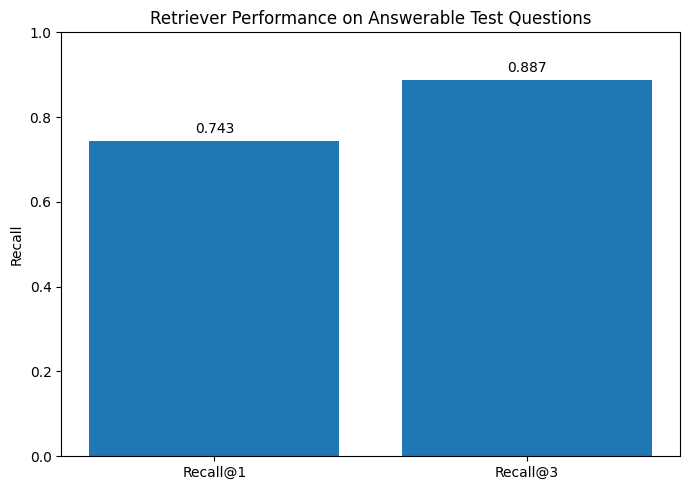

Figure saved to: results/retrieval_recall_answerable.png


In [29]:
answerable_test_metrics = test_metrics[
    test_metrics["subset"] == "Answerable"
].iloc[0]

metric_names = [
    "Recall@1",
    "Recall@3"
]

metric_values = [
    answerable_test_metrics["recall_at_1"],
    answerable_test_metrics["recall_at_3"]
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title(
    "Retriever Performance on Answerable Test Questions"
)

for bar, value in zip(
    bars,
    metric_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

figure_path = (
    RESULTS_DIR
    / "retrieval_recall_answerable.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

### cell30.

prints a short summary of the answerable test retrieval results.

In [30]:
answerable_metrics_row = test_metrics[
    test_metrics["subset"] == "Answerable"
].iloc[0]

answerable_count = int(
    answerable_metrics_row[
        "number_of_questions"
    ]
)

recall_1 = float(
    answerable_metrics_row[
        "recall_at_1"
    ]
)

recall_3 = float(
    answerable_metrics_row[
        "recall_at_3"
    ]
)

top1_correct_count = round(
    answerable_count * recall_1
)

top3_correct_count = round(
    answerable_count * recall_3
)

print("RETRIEVAL SUMMARY")
print("-" * 60)

print(
    f"Answerable test questions: "
    f"{answerable_count}"
)

print(
    f"Source context retrieved at Rank 1: "
    f"{top1_correct_count} "
    f"({recall_1:.3%})"
)

print(
    f"Source context retrieved in Top 3: "
    f"{top3_correct_count} "
    f"({recall_3:.3%})"
)

print(
    f"Retrieval misses outside Top 3: "
    f"{answerable_count - top3_correct_count}"
)

RETRIEVAL SUMMARY
------------------------------------------------------------
Answerable test questions: 400
Source context retrieved at Rank 1: 297 (74.250%)
Source context retrieved in Top 3: 355 (88.750%)
Retrieval misses outside Top 3: 45


### cell31.

installs the libraries needed for answer generation.

In [31]:
!pip install -q \
    transformers \
    sentencepiece \
    accelerate \
    tqdm

### cell32.

imports the libraries needed for generation, evaluation, and checkpoints.

In [32]:
from pathlib import Path
from collections import Counter

import json
import re
import string
import textwrap

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)


DATA_DIR = Path("data")
RESULTS_DIR = Path("results")

RESULTS_DIR.mkdir(exist_ok=True)


required_files = [
    DATA_DIR / "corpus.csv",
    RESULTS_DIR / "development_retrieval.jsonl",
    RESULTS_DIR / "test_retrieval.jsonl",
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "These files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nRun the Retriever cells first."
    )


corpus_df = pd.read_csv(
    DATA_DIR / "corpus.csv"
)

development_results = pd.read_json(
    RESULTS_DIR / "development_retrieval.jsonl",
    lines=True
)

test_results = pd.read_json(
    RESULTS_DIR / "test_retrieval.jsonl",
    lines=True
)


corpus_df["context_id"] = (
    corpus_df["context_id"].astype(int)
)

for dataframe in [
    development_results,
    test_results
]:
    dataframe["context_id"] = (
        dataframe["context_id"].astype(int)
    )

    dataframe["is_answerable"] = (
        dataframe["is_answerable"].astype(bool)
    )

    dataframe["source_context_in_top3"] = (
        dataframe[
            "source_context_in_top3"
        ].astype(bool)
    )


context_lookup = (
    corpus_df
    .set_index("context_id")["context"]
    .to_dict()
)


print("Corpus contexts:", len(corpus_df))

print(
    "Development questions:",
    len(development_results)
)

print(
    "Test questions:",
    len(test_results)
)

display(
    development_results[
        [
            "question",
            "is_answerable",
            "retrieved_context_ids",
            "source_context_in_top3"
        ]
    ].head()
)

Corpus contexts: 686
Development questions: 200
Test questions: 800


,question,is_answerable,retrieved_context_ids,source_context_in_top3
0,What did not set out the main provision on equ...,False,"[363, 364, 356]",True
1,Who commissioned the Tapestry?,True,"[35, 256, 225]",True
2,What group fully funds preschool?,False,"[608, 740, 616]",True
3,What are regions anchored by that are recogniz...,False,"[1047, 509, 107]",True
4,What can a simultaneous hermaphrodite do?,True,"[412, 393, 402]",True


### cell33.

loads the pretrained `FLAN-T5-small` tokenizer and generator model.

In [33]:
GENERATOR_MODEL_NAME = (
    "google/flan-t5-small"
)

GENERATOR_DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Generator device:", GENERATOR_DEVICE)

print(
    "Loading generator model:",
    GENERATOR_MODEL_NAME
)


generator_tokenizer = (
    AutoTokenizer.from_pretrained(
        GENERATOR_MODEL_NAME
    )
)

generator_model = (
    AutoModelForSeq2SeqLM.from_pretrained(
        GENERATOR_MODEL_NAME
    )
)

generator_model = generator_model.to(
    GENERATOR_DEVICE
)

generator_model.eval()


MAX_INPUT_TOKENS = 512

ABSTAIN_TOKEN = (
    "NOT_ENOUGH_INFORMATION"
)


print("Generator loaded successfully.")
print("Maximum input tokens:", MAX_INPUT_TOKENS)

Generator device: cuda
Loading generator model: google/flan-t5-small


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generator loaded successfully.
Maximum input tokens: 512


### cell34.

defines a grounded RAG prompt that says `unanswerable` when evidence is missing.

In [34]:
PROMPT_VERSION = "grounded_prompt_v1"


def count_generator_tokens(text):
    """
    Count how many FLAN-T5 tokens a text uses.
    """

    token_ids = generator_tokenizer.encode(
        str(text),
        add_special_tokens=False
    )

    return len(token_ids)


def extract_gold_answers(answers):
    """
    Extract reference answers from the SQuAD format.
    """

    if not isinstance(answers, dict):
        return []

    answer_texts = answers.get(
        "text",
        []
    )

    return [
        str(answer).strip()
        for answer in answer_texts
        if str(answer).strip()
    ]


def build_rag_prompt(
    question,
    retrieved_context_ids,
    max_input_tokens=512
):
    """
    Build a prompt containing:
    - instructions
    - retrieved evidence
    - the question

    The prompt stays within the model's
    input-token limit.
    """

    instruction = (
        "You are a careful question-answering "
        "assistant.\n"
        "Use only the evidence below.\n"
        "Do not use outside knowledge.\n"
        "If the answer is not explicitly supported "
        "by the evidence, output exactly:\n"
        f"{ABSTAIN_TOKEN}\n"
        "Return only a short answer. "
        "Do not explain your reasoning."
    )

    suffix = (
        f"\n\nQuestion:\n{question}"
        "\n\nAnswer:"
    )

    prompt = instruction

    for rank, context_id in enumerate(
        retrieved_context_ids,
        start=1
    ):
        context_id = int(context_id)

        context_text = str(
            context_lookup[context_id]
        )

        header = (
            f"\n\nEvidence {rank}:\n"
        )

        remaining_tokens = (
            max_input_tokens
            - count_generator_tokens(
                prompt + header + suffix
            )
            - 2
        )

        if remaining_tokens <= 0:
            break

        context_token_ids = (
            generator_tokenizer.encode(
                context_text,
                add_special_tokens=False
            )
        )

        selected_token_ids = (
            context_token_ids[
                :remaining_tokens
            ]
        )

        selected_context = (
            generator_tokenizer.decode(
                selected_token_ids,
                skip_special_tokens=True
            )
        )

        prompt += header + selected_context

        # If this context was already cut,
        # there is no room for more contexts.
        if (
            len(selected_token_ids)
            < len(context_token_ids)
        ):
            break

    final_prompt = prompt + suffix

    return final_prompt

### cell35.

builds and displays one example prompt and its token count.

In [35]:
example_row = (
    development_results.iloc[0]
)

example_prompt = build_rag_prompt(
    question=example_row["question"],
    retrieved_context_ids=(
        example_row[
            "retrieved_context_ids"
        ]
    ),
    max_input_tokens=MAX_INPUT_TOKENS
)


print(example_prompt)

print("\n" + "=" * 80)

print(
    "Prompt token count:",
    count_generator_tokens(
        example_prompt
    )
)

You are a careful question-answering assistant.
Use only the evidence below.
Do not use outside knowledge.
If the answer is not explicitly supported by the evidence, output exactly:
NOT_ENOUGH_INFORMATION
Return only a short answer. Do not explain your reasoning.

Evidence 1:
Since its foundation, the Treaties sought to enable people to pursue their life goals in any country through free movement. Reflecting the economic nature of the project, the European Community originally focused upon free movement of workers: as a "factor of production". However, from the 1970s, this focus shifted towards developing a more "social" Europe. Free movement was increasingly based on "citizenship", so that people had rights to empower them to become economically and socially active, rather than economic activity being a precondition for rights. This means the basic "worker" rights in TFEU article 45 function as a specific expression of the general rights of citizens in TFEU articles 18 to 21. Accordin

### cell36.

defines deterministic batch answer generation using FLAN-T5.

In [36]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


GENERATION_BATCH_SIZE = (
    8
    if GENERATOR_DEVICE == "cuda"
    else 2
)


def generate_answer_batch(
    prompts,
    max_new_tokens=32
):
    """
    Generate one short answer for each prompt.
    """

    encoded_inputs = (
        generator_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_TOKENS
        )
    )

    encoded_inputs = {
        key: value.to(GENERATOR_DEVICE)
        for key, value
        in encoded_inputs.items()
    }

    with torch.inference_mode():
        generated_token_ids = (
            generator_model.generate(
                **encoded_inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                num_beams=1
            )
        )

    generated_answers = (
        generator_tokenizer.batch_decode(
            generated_token_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )
    )

    return [
        answer.strip()
        for answer in generated_answers
    ]

### cell37.

tests generation on 3 answerable and 3 unanswerable development questions.

In [37]:
answerable_examples = (
    development_results[
        development_results[
            "is_answerable"
        ]
    ]
    .head(3)
)

unanswerable_examples = (
    development_results[
        ~development_results[
            "is_answerable"
        ]
    ]
    .head(3)
)

smoke_test_df = pd.concat(
    [
        answerable_examples,
        unanswerable_examples
    ],
    ignore_index=True
).copy()


smoke_test_df["prompt"] = (
    smoke_test_df.apply(
        lambda row: build_rag_prompt(
            question=row["question"],
            retrieved_context_ids=row[
                "retrieved_context_ids"
            ],
            max_input_tokens=(
                MAX_INPUT_TOKENS
            )
        ),
        axis=1
    )
)


smoke_test_df["generated_answer"] = (
    generate_answer_batch(
        smoke_test_df[
            "prompt"
        ].tolist()
    )
)


smoke_test_df["gold_answers"] = (
    smoke_test_df["answers"].apply(
        extract_gold_answers
    )
)


display(
    smoke_test_df[
        [
            "question",
            "is_answerable",
            "gold_answers",
            "generated_answer",
            "source_context_in_top3"
        ]
    ]
)

,question,is_answerable,gold_answers,generated_answer,source_context_in_top3
0,Who commissioned the Tapestry?,True,"[Odo, Odo, Odo]","Odo, the Bishop of Bayeux and first Earl of Kent",True
1,What can a simultaneous hermaphrodite do?,True,[can produce both eggs and sperm at the same t...,produce both eggs and sperm at the same time,True
2,What is the annual construction industry reven...,True,"[$960 billion, $960 billion, $960 billion]",$960 billion,True
3,What did not set out the main provision on equ...,False,[],"A job, however, need not be paid in money for ...",True
4,What group fully funds preschool?,False,[],aided schools,True
5,What are regions anchored by that are recogniz...,False,[],Orientalism,True


### cell38.

defines checkpointed batch generation that can resume after interruption.

In [38]:
def run_generation_with_checkpoint(
    input_df,
    checkpoint_path,
    batch_size=8
):
    """
    Generate answers in batches.

    Save progress after every batch so that
    Colab can resume after interruption.
    """

    checkpoint_path = Path(
        checkpoint_path
    )

    working_df = (
        input_df
        .copy()
        .reset_index(drop=True)
    )

    working_df["prompt_version"] = (
        PROMPT_VERSION
    )

    working_df["generator_model"] = (
        GENERATOR_MODEL_NAME
    )

    working_df["prompt"] = (
        working_df.apply(
            lambda row: build_rag_prompt(
                question=row["question"],
                retrieved_context_ids=row[
                    "retrieved_context_ids"
                ],
                max_input_tokens=(
                    MAX_INPUT_TOKENS
                )
            ),
            axis=1
        )
    )

    generated_answers = []
    start_index = 0

    if checkpoint_path.exists():
        saved_df = pd.read_json(
            checkpoint_path,
            lines=True
        )

        if (
            len(saved_df) > 0
            and "generated_answer"
            in saved_df.columns
        ):
            saved_ids = (
                saved_df["id"]
                .astype(str)
                .tolist()
            )

            expected_ids = (
                working_df
                .iloc[:len(saved_df)]["id"]
                .astype(str)
                .tolist()
            )

            if saved_ids != expected_ids:
                raise ValueError(
                    "Checkpoint questions do not "
                    "match the current dataset."
                )

            generated_answers = (
                saved_df[
                    "generated_answer"
                ]
                .fillna("")
                .astype(str)
                .tolist()
            )

            start_index = len(
                generated_answers
            )

            print(
                "Resuming from question:",
                start_index
            )

    progress_range = range(
        start_index,
        len(working_df),
        batch_size
    )

    for batch_start in tqdm(
        progress_range,
        desc="Generating answers"
    ):
        batch_end = min(
            batch_start + batch_size,
            len(working_df)
        )

        batch_prompts = (
            working_df
            .iloc[
                batch_start:batch_end
            ]["prompt"]
            .tolist()
        )

        batch_answers = (
            generate_answer_batch(
                batch_prompts
            )
        )

        generated_answers.extend(
            batch_answers
        )

        completed_count = len(
            generated_answers
        )

        partial_df = (
            working_df
            .iloc[:completed_count]
            .copy()
        )

        partial_df[
            "generated_answer"
        ] = generated_answers

        partial_df.to_json(
            checkpoint_path,
            orient="records",
            lines=True,
            force_ascii=False
        )

    final_df = working_df.copy()

    final_df[
        "generated_answer"
    ] = generated_answers

    return final_df

### cell39.

generates and saves answers for all development questions.

In [39]:
development_generation = (
    run_generation_with_checkpoint(
        input_df=development_results,
        checkpoint_path=(
            RESULTS_DIR
            / "development_generation.jsonl"
        ),
        batch_size=(
            GENERATION_BATCH_SIZE
        )
    )
)


print(
    "Development generation finished."
)

display(
    development_generation[
        [
            "question",
            "is_answerable",
            "generated_answer"
        ]
    ].head(10)
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors


Resuming from question: 200


Generating answers: 0it [00:00, ?it/s]

Development generation finished.


,question,is_answerable,generated_answer
0,What did not set out the main provision on equ...,False,"A job, however, need not be paid in money for ..."
1,Who commissioned the Tapestry?,True,"Odo, the Bishop of Bayeux and first Earl of Kent"
2,What group fully funds preschool?,False,aided schools
3,What are regions anchored by that are recogniz...,False,Orientalism
4,What can a simultaneous hermaphrodite do?,True,produce both eggs and sperm at the same time
5,Who won the PZPN Championship in 2000?,False,Polonia Warsaw
6,What is the annual construction industry reven...,True,$960 billion
7,What do some believe the Treaty of Versailles ...,True,Adolf Hitler's rise to power
8,What is the kilogram-force sometimes reffered ...,True,kilopond
9,"When dating rocks, what is the absolute isotop...",True,fossil sequences


### cell40.

defines text normalization, Exact Match, and token-level F1.

In [40]:
def normalize_qa_text(text):
    """
    Normalize text before comparing answers.
    """

    text = str(text).lower()

    text = "".join(
        character
        for character in text
        if character
        not in string.punctuation
    )

    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text
    )

    text = " ".join(
        text.split()
    )

    return text


def is_abstention_answer(text):
    """
    Detect NOT_ENOUGH_INFORMATION even if
    spaces, underscores or punctuation differ.
    """

    compact_text = re.sub(
        r"[^a-z]",
        "",
        str(text).lower()
    )

    return (
        compact_text
        == "notenoughinformation"
    )


def exact_match_score(
    prediction,
    gold_answer
):
    return float(
        normalize_qa_text(prediction)
        == normalize_qa_text(gold_answer)
    )


def token_f1_score(
    prediction,
    gold_answer
):
    prediction_tokens = (
        normalize_qa_text(
            prediction
        ).split()
    )

    gold_tokens = (
        normalize_qa_text(
            gold_answer
        ).split()
    )

    if (
        len(prediction_tokens) == 0
        or len(gold_tokens) == 0
    ):
        return float(
            prediction_tokens
            == gold_tokens
        )

    common_tokens = (
        Counter(prediction_tokens)
        & Counter(gold_tokens)
    )

    number_of_common_tokens = sum(
        common_tokens.values()
    )

    if number_of_common_tokens == 0:
        return 0.0

    precision = (
        number_of_common_tokens
        / len(prediction_tokens)
    )

    recall = (
        number_of_common_tokens
        / len(gold_tokens)
    )

    f1 = (
        2
        * precision
        * recall
        / (precision + recall)
    )

    return float(f1)


def best_score_against_gold_answers(
    prediction,
    gold_answers,
    scoring_function
):
    if not gold_answers:
        return 0.0

    scores = [
        scoring_function(
            prediction,
            gold_answer
        )
        for gold_answer
        in gold_answers
    ]

    return float(max(scores))


def attach_generation_evaluation(
    generation_df
):
    """
    Add evaluation columns to generated answers.
    """

    evaluated_df = (
        generation_df.copy()
    )

    evaluated_df[
        "gold_answers"
    ] = evaluated_df[
        "answers"
    ].apply(
        extract_gold_answers
    )

    evaluated_df[
        "is_generation_failure"
    ] = evaluated_df[
        "generated_answer"
    ].apply(
        lambda answer:
        len(str(answer).strip()) == 0
    )

    evaluated_df[
        "is_abstention"
    ] = evaluated_df[
        "generated_answer"
    ].apply(
        is_abstention_answer
    )

    exact_match_values = []
    answer_f1_values = []

    for _, row in (
        evaluated_df.iterrows()
    ):
        if bool(
            row["is_answerable"]
        ):
            gold_answers = row[
                "gold_answers"
            ]

            prediction = row[
                "generated_answer"
            ]

            exact_match_values.append(
                best_score_against_gold_answers(
                    prediction,
                    gold_answers,
                    exact_match_score
                )
            )

            answer_f1_values.append(
                best_score_against_gold_answers(
                    prediction,
                    gold_answers,
                    token_f1_score
                )
            )

        else:
            exact_match_values.append(
                np.nan
            )

            answer_f1_values.append(
                np.nan
            )

    evaluated_df[
        "answer_exact_match"
    ] = exact_match_values

    evaluated_df[
        "answer_f1"
    ] = answer_f1_values

    evaluated_df[
        "retrieval_success"
    ] = evaluated_df[
        "source_context_in_top3"
    ].astype(bool)

    evaluated_df[
        "over_abstention"
    ] = (
        evaluated_df[
            "is_answerable"
        ]
        & evaluated_df[
            "is_abstention"
        ]
    )

    evaluated_df[
        "hallucination"
    ] = (
        ~evaluated_df[
            "is_answerable"
        ]
        & ~evaluated_df[
            "is_abstention"
        ]
        & ~evaluated_df[
            "is_generation_failure"
        ]
    )

    return evaluated_df

### cell41.

defines summary metrics for answerable and unanswerable generated answers.

In [41]:
def calculate_generation_metrics(
    evaluated_df
):
    answerable_df = evaluated_df[
        evaluated_df["is_answerable"]
    ]

    unanswerable_df = evaluated_df[
        ~evaluated_df["is_answerable"]
    ]

    rows = [
        {
            "subset": "Answerable",
            "metric": "Exact Match",
            "value": (
                answerable_df[
                    "answer_exact_match"
                ].mean()
            ),
            "number_of_questions": (
                len(answerable_df)
            )
        },
        {
            "subset": "Answerable",
            "metric": "Token F1",
            "value": (
                answerable_df[
                    "answer_f1"
                ].mean()
            ),
            "number_of_questions": (
                len(answerable_df)
            )
        },
        {
            "subset": "Answerable",
            "metric": (
                "Over-abstention Rate"
            ),
            "value": (
                answerable_df[
                    "over_abstention"
                ].mean()
            ),
            "number_of_questions": (
                len(answerable_df)
            )
        },
        {
            "subset": "Unanswerable",
            "metric": (
                "Correct Abstention Rate"
            ),
            "value": (
                unanswerable_df[
                    "is_abstention"
                ].mean()
            ),
            "number_of_questions": (
                len(unanswerable_df)
            )
        },
        {
            "subset": "Unanswerable",
            "metric": (
                "Hallucination Rate"
            ),
            "value": (
                unanswerable_df[
                    "hallucination"
                ].mean()
            ),
            "number_of_questions": (
                len(unanswerable_df)
            )
        },
        {
            "subset": "All",
            "metric": (
                "Generation Failure Rate"
            ),
            "value": (
                evaluated_df[
                    "is_generation_failure"
                ].mean()
            ),
            "number_of_questions": (
                len(evaluated_df)
            )
        }
    ]

    return pd.DataFrame(rows)

### cell42.

evaluates and displays the generated development answers.

In [42]:
development_evaluated = (
    attach_generation_evaluation(
        development_generation
    )
)


development_generation_metrics = (
    calculate_generation_metrics(
        development_evaluated
    )
)


display(
    development_generation_metrics
    .style
    .format(
        {
            "value": "{:.3f}"
        }
    )
)

,subset,metric,value,number_of_questions
0,Answerable,Exact Match,0.530,100
1,Answerable,Token F1,0.609,100
2,Answerable,Over-abstention Rate,0.000,100
3,Unanswerable,Correct Abstention Rate,0.010,100
4,Unanswerable,Hallucination Rate,0.990,100
5,All,Generation Failure Rate,0.000,200


### cell43.

separates retrieval failures from generation failures.

In [43]:
def calculate_retrieval_generation_breakdown(
    evaluated_df
):
    rows = []

    configurations = [
        (
            "Answerable",
            True
        ),
        (
            "Unanswerable",
            False
        )
    ]

    for subset_name, answerable_value in (
        configurations
    ):
        subset_df = evaluated_df[
            evaluated_df[
                "is_answerable"
            ] == answerable_value
        ]

        for retrieval_success in [
            True,
            False
        ]:
            group_df = subset_df[
                subset_df[
                    "retrieval_success"
                ] == retrieval_success
            ]

            row = {
                "subset": subset_name,
                "retrieval_status": (
                    "Gold context in Top-3"
                    if retrieval_success
                    else "Gold context outside Top-3"
                ),
                "number_of_questions": (
                    len(group_df)
                ),
                "exact_match": np.nan,
                "token_f1": np.nan,
                "over_abstention_rate": np.nan,
                "correct_abstention_rate": np.nan,
                "hallucination_rate": np.nan
            }

            if len(group_df) > 0:
                if answerable_value:
                    row[
                        "exact_match"
                    ] = group_df[
                        "answer_exact_match"
                    ].mean()

                    row[
                        "token_f1"
                    ] = group_df[
                        "answer_f1"
                    ].mean()

                    row[
                        "over_abstention_rate"
                    ] = group_df[
                        "over_abstention"
                    ].mean()

                else:
                    row[
                        "correct_abstention_rate"
                    ] = group_df[
                        "is_abstention"
                    ].mean()

                    row[
                        "hallucination_rate"
                    ] = group_df[
                        "hallucination"
                    ].mean()

            rows.append(row)

    return pd.DataFrame(rows)


development_breakdown = (
    calculate_retrieval_generation_breakdown(
        development_evaluated
    )
)


display(
    development_breakdown
    .style
    .format(
        {
            "exact_match": "{:.3f}",
            "token_f1": "{:.3f}",
            "over_abstention_rate": "{:.3f}",
            "correct_abstention_rate": "{:.3f}",
            "hallucination_rate": "{:.3f}"
        },
        na_rep="-"
    )
)

,subset,retrieval_status,number_of_questions,exact_match,token_f1,over_abstention_rate,correct_abstention_rate,hallucination_rate
0,Answerable,Gold context in Top-3,84,0.619,0.708,0.000,-,-
1,Answerable,Gold context outside Top-3,16,0.062,0.087,0.000,-,-
2,Unanswerable,Gold context in Top-3,75,-,-,-,0.000,1.000
3,Unanswerable,Gold context outside Top-3,25,-,-,-,0.040,0.960


### cell44.

creates a table for manually reviewing evidence and hallucination cases.

In [44]:
def make_context_excerpt(
    context_ids,
    max_characters=350
):
    if (
        not isinstance(
            context_ids,
            list
        )
        or len(context_ids) == 0
    ):
        return ""

    top_context_id = int(
        context_ids[0]
    )

    text = str(
        context_lookup[
            top_context_id
        ]
    ).replace(
        "\n",
        " "
    )

    return textwrap.shorten(
        text,
        width=max_characters,
        placeholder=" ..."
    )


development_evaluated[
    "top_context_excerpt"
] = development_evaluated[
    "retrieved_context_ids"
].apply(
    make_context_excerpt
)


development_hallucinations = (
    development_evaluated[
        development_evaluated[
            "hallucination"
        ]
    ]
)


print(
    "Development hallucinations:",
    len(development_hallucinations)
)


display(
    development_hallucinations[
        [
            "question",
            "generated_answer",
            "top_context_excerpt",
            "retrieval_success"
        ]
    ].head(10)
)

Development hallucinations: 99


,question,generated_answer,top_context_excerpt,retrieval_success
0,What did not set out the main provision on equ...,"A job, however, need not be paid in money for ...","Since its foundation, the Treaties sought to e...",True
2,What group fully funds preschool?,aided schools,The other category of schools are those run an...,True
3,What are regions anchored by that are recogniz...,Orientalism,According to geographic scholars under coloniz...,True
5,Who won the PZPN Championship in 2000?,Polonia Warsaw,"Their local rivals, Polonia Warsaw, have signi...",True
11,Who disagrees with the timetable of business i...,MSPs,"Each sitting day, normally at 5 pm, MSPs decid...",False
13,When was the function hypothesis proposed?,1970s,Studies on income inequality and growth have s...,False
17,How was france the same as Britain in managing...,France sent small numbers of settlers to its c...,The outcome was one of the most significant de...,True
18,When did the Jip dynasty begin?,1368,The Yuan dynasty (Chinese: 元朝; pinyin: Yuán Ch...,False
22,What is one type of private key cryptography a...,RSA,"Several public-key cryptography algorithms, su...",True
25,What group needs to decide if they should make...,civil disobedients,An important decision for civil disobedients i...,True


### cell45.

generates and checkpoints answers for all test questions.

In [45]:
test_generation = (
    run_generation_with_checkpoint(
        input_df=test_results,
        checkpoint_path=(
            RESULTS_DIR
            / "test_generation.jsonl"
        ),
        batch_size=(
            GENERATION_BATCH_SIZE
        )
    )
)


print("Test generation finished.")

display(
    test_generation[
        [
            "question",
            "is_answerable",
            "generated_answer"
        ]
    ].head()
)

Resuming from question: 800


Generating answers: 0it [00:00, ?it/s]

Test generation finished.


,question,is_answerable,generated_answer
0,Who was Bohemond's son?,False,Robert
1,"What line is at 30 degrees, 36 minutes?",False,1.1 °C
2,Who were later Yuan emperors isolated with?,False,army and populace
3,What government department did Buyantu shut down?,True,US Secretary of State Henry Kissinger
4,What is a a developing economy's level of ineq...,True,a market economy


### cell46.

calculates final test generation metrics and the retrieval/generation breakdown.

In [46]:
test_evaluated = (
    attach_generation_evaluation(
        test_generation
    )
)


test_generation_metrics = (
    calculate_generation_metrics(
        test_evaluated
    )
)


test_breakdown = (
    calculate_retrieval_generation_breakdown(
        test_evaluated
    )
)


print("FINAL GENERATION METRICS")

display(
    test_generation_metrics
    .style
    .format(
        {
            "value": "{:.3f}"
        }
    )
)


print(
    "\nRETRIEVAL–GENERATION BREAKDOWN"
)

display(
    test_breakdown
    .style
    .format(
        {
            "exact_match": "{:.3f}",
            "token_f1": "{:.3f}",
            "over_abstention_rate": "{:.3f}",
            "correct_abstention_rate": "{:.3f}",
            "hallucination_rate": "{:.3f}"
        },
        na_rep="-"
    )
)

FINAL GENERATION METRICS


,subset,metric,value,number_of_questions
0,Answerable,Exact Match,0.552,400
1,Answerable,Token F1,0.662,400
2,Answerable,Over-abstention Rate,0.003,400
3,Unanswerable,Correct Abstention Rate,0.013,400
4,Unanswerable,Hallucination Rate,0.988,400
5,All,Generation Failure Rate,0.000,800



RETRIEVAL–GENERATION BREAKDOWN


,subset,retrieval_status,number_of_questions,exact_match,token_f1,over_abstention_rate,correct_abstention_rate,hallucination_rate
0,Answerable,Gold context in Top-3,355,0.623,0.738,0.000,-,-
1,Answerable,Gold context outside Top-3,45,0.000,0.061,0.022,-,-
2,Unanswerable,Gold context in Top-3,320,-,-,-,0.006,0.994
3,Unanswerable,Gold context outside Top-3,80,-,-,-,0.037,0.963


### cell47.

assigns preliminary labels to retrieval, hallucination, and generation errors.

In [47]:
def classify_error_candidate(row):
    """
    Create preliminary error labels.

    Some labels still need manual inspection.
    """

    if bool(
        row["is_generation_failure"]
    ):
        return "generation_failure"

    if not bool(
        row["is_answerable"]
    ):
        if bool(
            row["hallucination"]
        ):
            return (
                "absent_evidence_hallucination"
            )

        return "no_clear_error"

    if float(
        row["answer_f1"]
    ) >= 0.5:
        return "no_clear_error"

    if not bool(
        row["retrieval_success"]
    ):
        return (
            "retrieval_miss_candidate"
        )

    if bool(
        row["over_abstention"]
    ):
        return "over_abstention"

    return (
        "wrong_answer_despite_"
        "retrieved_evidence_candidate"
    )


test_evaluated[
    "error_candidate"
] = test_evaluated.apply(
    classify_error_candidate,
    axis=1
)


test_evaluated[
    "top_context_excerpt"
] = test_evaluated[
    "retrieved_context_ids"
].apply(
    make_context_excerpt
)


error_candidates = (
    test_evaluated[
        test_evaluated[
            "error_candidate"
        ] != "no_clear_error"
    ]
    .copy()
)


error_candidates[
    "gold_answers_display"
] = error_candidates[
    "gold_answers"
].apply(
    lambda answers:
    " | ".join(answers)
)


display(
    error_candidates[
        [
            "question",
            "is_answerable",
            "gold_answers_display",
            "generated_answer",
            "retrieval_success",
            "answer_f1",
            "error_candidate",
            "top_context_excerpt"
        ]
    ].head(20)
)


print(
    "\nError category counts:"
)

display(
    error_candidates[
        "error_candidate"
    ].value_counts()
)

,question,is_answerable,gold_answers_display,generated_answer,retrieval_success,answer_f1,error_candidate,top_context_excerpt
0,Who was Bohemond's son?,False,,Robert,True,NaN,absent_evidence_hallucination,"In 1096, Crusaders passing by the siege of Ama..."
1,"What line is at 30 degrees, 36 minutes?",False,,1.1 °C,False,NaN,absent_evidence_hallucination,There are also several smaller freight operato...
2,Who were later Yuan emperors isolated with?,False,,army and populace,True,NaN,absent_evidence_hallucination,"The fourth Yuan emperor, Buyantu Khan (Ayurbar..."
3,What government department did Buyantu shut down?,True,the Department of State Affairs | Department o...,US Secretary of State Henry Kissinger,False,0.4,retrieval_miss_candidate,During the divestment from South Africa moveme...
4,What is a a developing economy's level of ineq...,True,Kuznets curve | Kuznets curve | Kuznets curve,a market economy,False,0.0,retrieval_miss_candidate,In a purely capitalist mode of production (i.e...
7,What percentage of people died in Crimea of th...,False,,60%,True,NaN,absent_evidence_hallucination,The Black Death is thought to have originated ...
9,When did John of London come to live in Cambri...,False,,1,False,NaN,absent_evidence_hallucination,"When Céloron's expedition arrived at Logstown,..."
11,What was the Japanese name for the Central Se...,False,,Zhongshu Sheng,True,NaN,absent_evidence_hallucination,"The Central Region, consisting of present-day ..."
12,What is the name of the smallest university pr...,False,,University of Chicago Press,True,NaN,absent_evidence_hallucination,University of Chicago scholars have played a m...
13,What type of compounds does oxygen most common...,True,oxides | oxides | oxides | oxide compounds | o...,"glycerol, formaldehyde, glutaraldehyde, citric...",False,0.0,retrieval_miss_candidate,Among the most important classes of organic co...



Error category counts:


,count
error_candidate,
absent_evidence_hallucination,395
wrong_answer_despite_retrieved_evidence_candidate,82
retrieval_miss_candidate,44


### cell48.

saves final answers, metrics, breakdowns, and error-analysis files.

In [48]:
test_evaluated.to_json(
    RESULTS_DIR
    / "test_generation_evaluated.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)


test_generation_metrics.to_csv(
    RESULTS_DIR
    / "test_generation_metrics.csv",
    index=False
)


test_breakdown.to_csv(
    RESULTS_DIR
    / "retrieval_generation_breakdown.csv",
    index=False
)


error_candidates_for_csv = (
    error_candidates.copy()
)


for list_column in [
    "retrieved_context_ids",
    "retrieved_scores",
    "gold_answers"
]:
    if (
        list_column
        in error_candidates_for_csv.columns
    ):
        error_candidates_for_csv[
            list_column
        ] = error_candidates_for_csv[
            list_column
        ].apply(
            json.dumps
        )


error_candidates_for_csv.to_csv(
    RESULTS_DIR
    / "generation_error_candidates.csv",
    index=False
)


experiment_configuration = {
    "retriever_model": (
        "sentence-transformers/"
        "multi-qa-MiniLM-L6-cos-v1"
    ),
    "generator_model": (
        GENERATOR_MODEL_NAME
    ),
    "prompt_version": (
        PROMPT_VERSION
    ),
    "maximum_input_tokens": (
        MAX_INPUT_TOKENS
    ),
    "maximum_new_tokens": 32,
    "top_k_contexts": 3,
    "do_sample": False,
    "num_beams": 1,
    "abstention_token": (
        ABSTAIN_TOKEN
    ),
    "random_seed": 42
}


with open(
    RESULTS_DIR
    / "experiment_configuration.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        experiment_configuration,
        file,
        indent=2,
        ensure_ascii=False
    )


print("All final files were saved.")

All final files were saved.


### cell49.

draws and saves answerable and unanswerable generation metric charts.

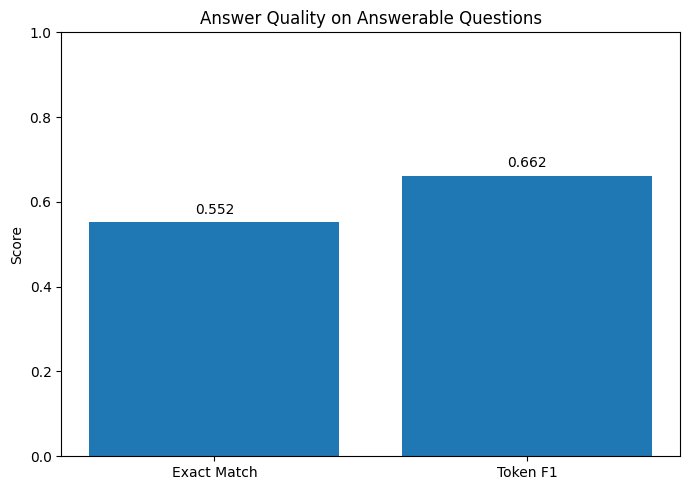

Saved to: results/answerable_generation_metrics.png


In [49]:
answerable_metrics = (
    test_generation_metrics[
        (
            test_generation_metrics[
                "subset"
            ] == "Answerable"
        )
        & (
            test_generation_metrics[
                "metric"
            ].isin(
                [
                    "Exact Match",
                    "Token F1"
                ]
            )
        )
    ]
)


plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    answerable_metrics[
        "metric"
    ],
    answerable_metrics[
        "value"
    ]
)

plt.ylim(0, 1)

plt.ylabel("Score")

plt.title(
    "Answer Quality on Answerable Questions"
)

for bar, value in zip(
    bars,
    answerable_metrics["value"]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

answerable_figure_path = (
    RESULTS_DIR
    / "answerable_generation_metrics.png"
)

plt.savefig(
    answerable_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    answerable_figure_path
)

### cell50.

prints a short final summary of retrieval, generation, and common errors.

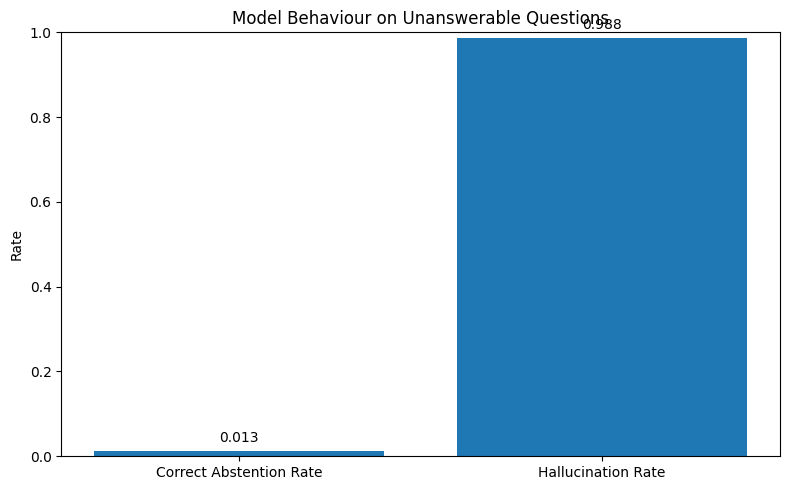

Saved to: results/unanswerable_generation_behavior.png


In [50]:
unanswerable_metrics = (
    test_generation_metrics[
        (
            test_generation_metrics[
                "subset"
            ] == "Unanswerable"
        )
        & (
            test_generation_metrics[
                "metric"
            ].isin(
                [
                    "Correct Abstention Rate",
                    "Hallucination Rate"
                ]
            )
        )
    ]
)


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    unanswerable_metrics[
        "metric"
    ],
    unanswerable_metrics[
        "value"
    ]
)

plt.ylim(0, 1)

plt.ylabel("Rate")

plt.title(
    "Model Behaviour on Unanswerable Questions"
)

for bar, value in zip(
    bars,
    unanswerable_metrics["value"]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

unanswerable_figure_path = (
    RESULTS_DIR
    / "unanswerable_generation_behavior.png"
)

plt.savefig(
    unanswerable_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    unanswerable_figure_path
)

### cell51.

loads the retriever for the demo only if it is not already in memory.

In [51]:
from sentence_transformers import (
    SentenceTransformer,
    util
)


RETRIEVER_MODEL_NAME = (
    "sentence-transformers/"
    "multi-qa-MiniLM-L6-cos-v1"
)


if "retrieval_model" not in globals():
    print("Loading retriever for demo...")

    retrieval_model = (
        SentenceTransformer(
            RETRIEVER_MODEL_NAME
        )
    )


demo_corpus_texts = (
    corpus_df["context"]
    .fillna("")
    .astype(str)
    .tolist()
)

demo_corpus_context_ids = (
    corpus_df["context_id"]
    .astype(int)
    .tolist()
)


if "demo_corpus_embeddings" not in globals():
    demo_corpus_embeddings = (
        retrieval_model.encode(
            demo_corpus_texts,
            batch_size=64,
            show_progress_bar=True,
            convert_to_tensor=True,
            normalize_embeddings=True
        )
    )


print("Demo retriever is ready.")

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Demo retriever is ready.


### cell52.

defines `ask_yadyar`, which retrieves evidence and generates one grounded answer.

In [52]:
def ask_yadyar(
    question,
    top_k=3,
    show_context_characters=400
):
    """
    Lightweight YadYar RAG demo.
    """

    question_embedding = (
        retrieval_model.encode(
            [str(question)],
            convert_to_tensor=True,
            normalize_embeddings=True
        )
    )

    hits = util.semantic_search(
        query_embeddings=(
            question_embedding
        ),
        corpus_embeddings=(
            demo_corpus_embeddings
        ),
        top_k=top_k,
        score_function=util.cos_sim
    )[0]

    retrieved_context_ids = []
    retrieved_scores = []

    for hit in hits:
        corpus_position = int(
            hit["corpus_id"]
        )

        context_id = int(
            demo_corpus_context_ids[
                corpus_position
            ]
        )

        retrieved_context_ids.append(
            context_id
        )

        retrieved_scores.append(
            float(hit["score"])
        )

    prompt = build_rag_prompt(
        question=question,
        retrieved_context_ids=(
            retrieved_context_ids
        ),
        max_input_tokens=(
            MAX_INPUT_TOKENS
        )
    )

    answer = generate_answer_batch(
        [prompt]
    )[0]

    print("=" * 90)

    print("QUESTION")
    print(question)

    print("\nRETRIEVED EVIDENCE")

    for rank, (
        context_id,
        score
    ) in enumerate(
        zip(
            retrieved_context_ids,
            retrieved_scores
        ),
        start=1
    ):
        context_text = str(
            context_lookup[
                context_id
            ]
        ).replace(
            "\n",
            " "
        )

        short_context = (
            textwrap.shorten(
                context_text,
                width=(
                    show_context_characters
                ),
                placeholder=" ..."
            )
        )

        print(
            f"\nRank {rank}"
            f" | Context ID: {context_id}"
            f" | Score: {score:.4f}"
        )

        print(short_context)

    print("\nGENERATED ANSWER")
    print(answer)

    print("=" * 90)

    return {
        "question": question,
        "retrieved_context_ids": (
            retrieved_context_ids
        ),
        "retrieved_scores": (
            retrieved_scores
        ),
        "answer": answer
    }

### cell53.

runs the YadYar demo on one test question.

In [53]:
demo_question = (
    test_results.iloc[0]["question"]
)

demo_output = ask_yadyar(
    demo_question
)

QUESTION
Who was Bohemond's son?

RETRIEVED EVIDENCE

Rank 1 | Context ID: 24 | Score: 0.4909
In 1096, Crusaders passing by the siege of Amalfi were joined by Bohemond of Taranto and his nephew Tancred with an army of Italo-Normans. Bohemond was the de facto leader of the Crusade during its passage through Asia Minor. After the successful Siege of Antioch in 1097, Bohemond began carving out an independent principality around that city. Tancred was instrumental in the conquest of ...

Rank 2 | Context ID: 12 | Score: 0.4285
A few years after the First Crusade, in 1107, the Normans under the command of Bohemond, Robert's son, landed in Valona and besieged Dyrrachium using the most sophisticated military equipment of the time, but to no avail. Meanwhile, they occupied Petrela, the citadel of Mili at the banks of the river Deabolis, Gllavenica (Ballsh), Kanina and Jericho. This time, the Albanians sided with the ...

Rank 3 | Context ID: 205 | Score: 0.3046
Prince Louis de Condé, along wit